In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Nov.csv
/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv


# Analyse du comportement des utilisateurs e-commerce
**Objectif :** Comprendre les habitudes d'achat des utilisateurs à partir d'un dataset réel.  
**Outils :** Python, Pandas, Matplotlib  
**Source :** Kaggle — eCommerce behavior data (mkechinov)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Chargement du dataset
df = pd.read_csv('/kaggle/input/datasets/mkechinov/ecommerce-behavior-data-from-multi-category-store/2019-Oct.csv')

# Aperçu des premières lignes
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [4]:
# Dimensions du dataset
print("Nombre de lignes et colonnes :", df.shape)

# Noms des colonnes
print("\nColonnes :", df.columns.tolist())

# Types de données de chaque colonne
print("\nTypes de données :")
print(df.dtypes)

Nombre de lignes et colonnes : (42448764, 9)

Colonnes : ['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']

Types de données :
event_time        object
event_type        object
product_id         int64
category_id        int64
category_code     object
brand             object
price            float64
user_id            int64
user_session      object
dtype: object


In [5]:
# Valeurs manquantes par colonne
print("Valeurs manquantes :")
print(df.isnull().sum())

# En pourcentage
print("\nPourcentage de valeurs manquantes :")
print((df.isnull().sum() / len(df) * 100).round(2))

Valeurs manquantes :
event_time              0
event_type              0
product_id              0
category_id             0
category_code    13515609
brand             6117080
price                   0
user_id                 0
user_session            2
dtype: int64

Pourcentage de valeurs manquantes :
event_time        0.00
event_type        0.00
product_id        0.00
category_id       0.00
category_code    31.84
brand            14.41
price             0.00
user_id           0.00
user_session      0.00
dtype: float64


In [6]:
# On supprime les lignes où category_code est vide
# car on en a besoin pour analyser les catégories
df_clean = df.dropna(subset=['category_code', 'brand'])

# Vérification
print("Taille avant nettoyage :", df.shape)
print("Taille après nettoyage :", df_clean.shape)
print("Lignes supprimées :", df.shape[0] - df_clean.shape[0])

Taille avant nettoyage : (42448764, 9)
Taille après nettoyage : (26560622, 9)
Lignes supprimées : 15888142


In [7]:
# Combien de vues, ajouts au panier et achats ?
print("Répartition des événements :")
print(df_clean['event_type'].value_counts())

print("\nEn pourcentage :")
print((df_clean['event_type'].value_counts() / len(df_clean) * 100).round(2))

Répartition des événements :
event_type
view        25201706
cart          809409
purchase      549507
Name: count, dtype: int64

En pourcentage :
event_type
view        94.88
cart         3.05
purchase     2.07
Name: count, dtype: float64


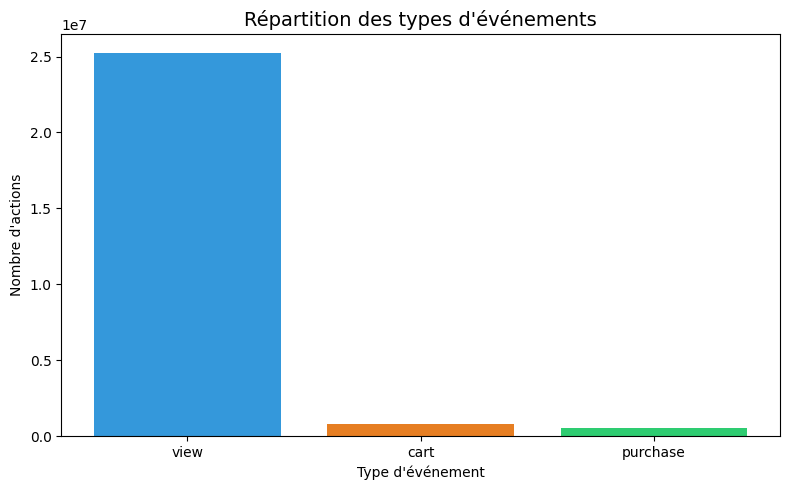

In [8]:
# Graphique de la répartition des événements
event_counts = df_clean['event_type'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(event_counts.index, event_counts.values, color=['#3498db', '#e67e22', '#2ecc71'])
plt.title('Répartition des types d\'événements', fontsize=14)
plt.xlabel('Type d\'événement')
plt.ylabel('Nombre d\'actions')
plt.tight_layout()
plt.show()

## Observation
Le graphique montre une très forte dominance des "view" (94.88%). 
Le taux de conversion view → purchase est de seulement 2.07%, 
ce qui indique un tunnel de vente peu efficace.

## 2. Analyse des catégories les plus populaires
Quelles sont les catégories de produits les plus vues et les plus achetées ?

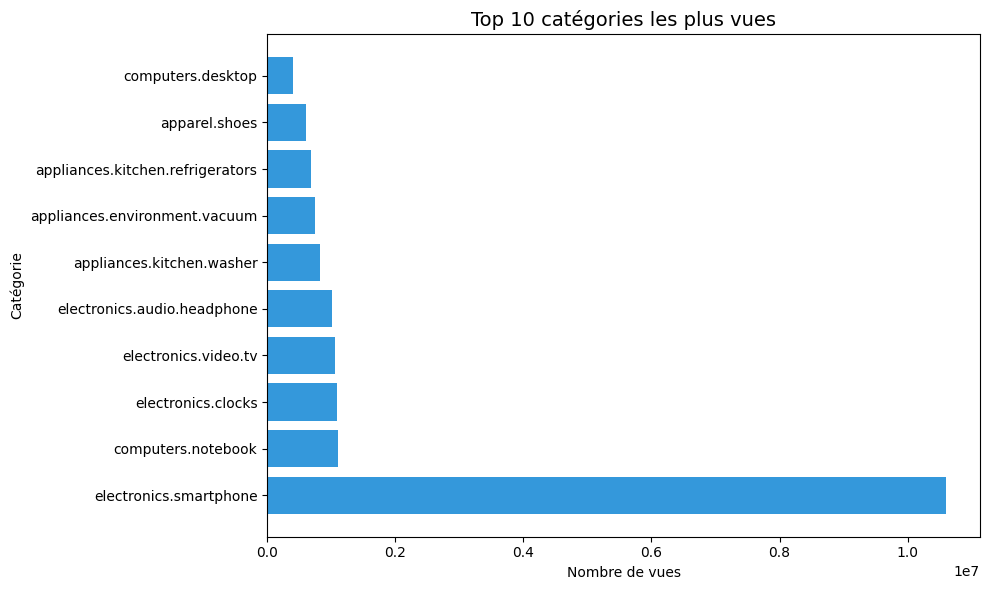

In [9]:
# Top 10 catégories les plus vues
top_categories = df_clean[df_clean['event_type'] == 'view']['category_code'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_categories.index, top_categories.values, color='#3498db')
plt.title('Top 10 catégories les plus vues', fontsize=14)
plt.xlabel('Nombre de vues')
plt.ylabel('Catégorie')
plt.tight_layout()
plt.show()

## Observation
Les smartphones (electronics.smartphone) dominent avec ~10M de vues, 
soit 10x plus que la 2ème catégorie. Ce site est clairement orienté électronique.

## 3. Analyse des marques les plus populaires
Quelles sont les marques les plus vues et les plus achetées ?

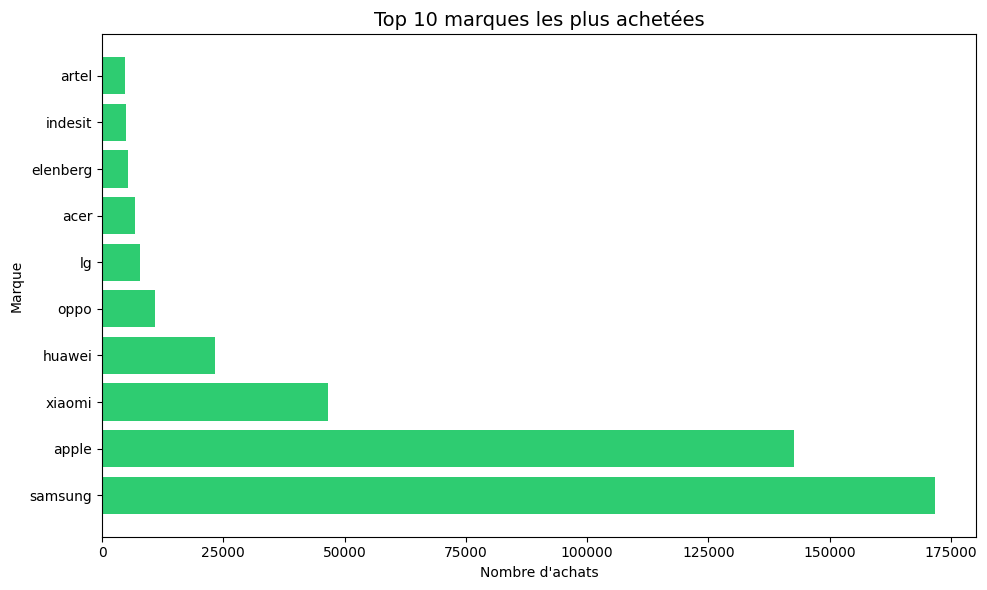

In [11]:
# Top 10 marques les plus achetées
top_brands = df_clean[df_clean['event_type'] == 'purchase']['brand'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_brands.index, top_brands.values, color='#2ecc71')
plt.title('Top 10 marques les plus achetées', fontsize=14)
plt.xlabel('Nombre d\'achats')
plt.ylabel('Marque')
plt.tight_layout()
plt.show()

## Observation
Samsung (170k achats) et Apple (140k achats) dominent largement le marché.
Ensemble ils représentent plus de 55% des achats du top 10.
Xiaomi arrive 3ème avec 47k achats — fort sur le segment entrée de gamme.

## 4. Analyse des heures d'activité
À quelles heures les utilisateurs sont-ils les plus actifs ?

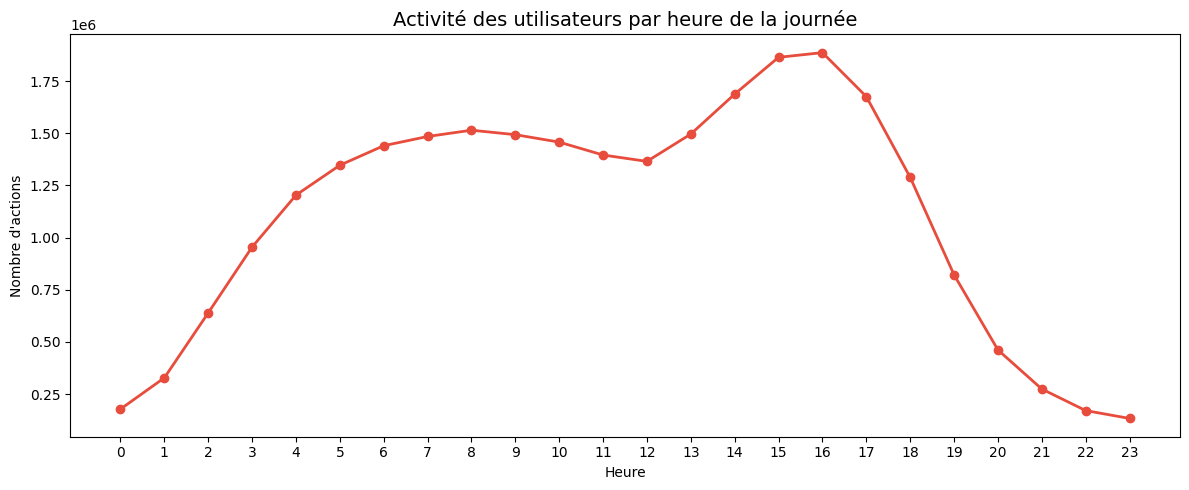

In [13]:
# Convertir event_time en format datetime
df_clean = df_clean.copy()
df_clean['event_time'] = pd.to_datetime(df_clean['event_time'])

# Extraire l'heure
df_clean['hour'] = df_clean['event_time'].dt.hour
# Compter les actions par heure
hourly_activity = df_clean.groupby('hour')['event_type'].count()

plt.figure(figsize=(12, 5))
plt.plot(hourly_activity.index, hourly_activity.values, color='#e74c3c', linewidth=2, marker='o')
plt.title('Activité des utilisateurs par heure de la journée', fontsize=14)
plt.xlabel('Heure')
plt.ylabel('Nombre d\'actions')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

## Observation
Le pic d'activité est à 16h avec ~1.9M d'actions.
L'activité est faible la nuit (0h-4h) et monte progressivement dès 4h du matin.
Recommandation : lancer les promotions entre 14h et 17h pour maximiser la visibilité.

## 5. Prix moyen par catégorie
Quelles catégories ont le prix moyen le plus élevé ?

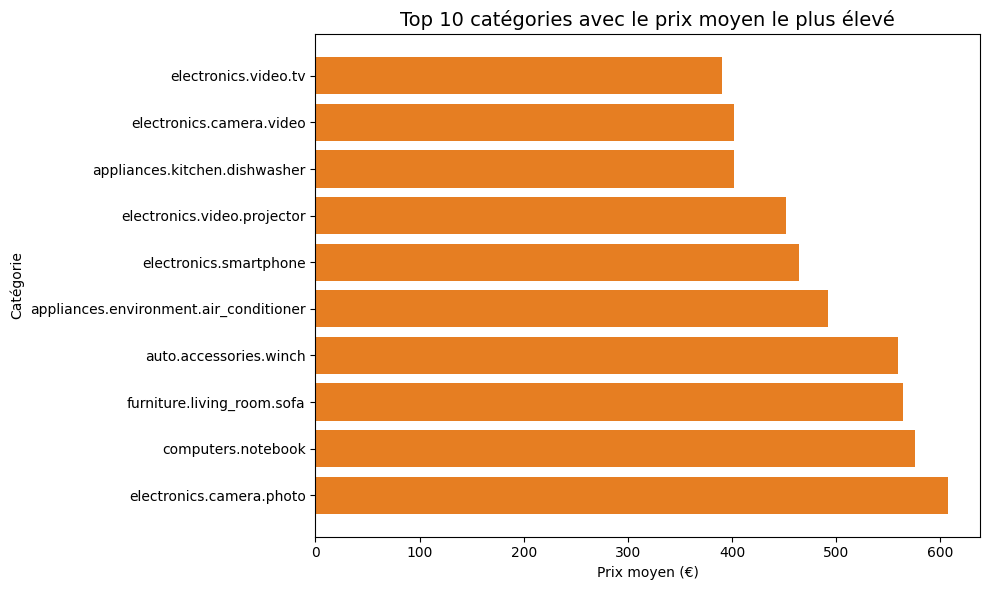

In [14]:
# Prix moyen par catégorie (top 10 catégories les plus achetées)
avg_price = df_clean[df_clean['event_type'] == 'purchase'].groupby('category_code')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(avg_price.index, avg_price.values, color='#e67e22')
plt.title('Top 10 catégories avec le prix moyen le plus élevé', fontsize=14)
plt.xlabel('Prix moyen (€)')
plt.ylabel('Catégorie')
plt.tight_layout()
plt.show()

## Observation
Les appareils photo (600€) et ordinateurs portables (575€) ont les prix moyens 
les plus élevés. Les smartphones à 470€ sont chers mais très achetés — 
les utilisateurs sont prêts à investir dans cette catégorie.

## Conclusion générale

**3 insights clés de cette analyse :**

1. **Taux de conversion très faible (2%)** — sur 100 visiteurs, seulement 2 achètent. 
Le site perd énormément de clients entre la consultation et l'achat.

2. **Les smartphones dominent** — catégorie la plus vue (10M) et Samsung/Apple 
représentent plus de 55% des achats.

3. **Pic d'activité à 16h** — meilleur moment pour lancer des promotions 
et maximiser la visibilité.